In [20]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler 
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, auc, roc_curve
import pickle

### LOAD DATA + DATA UNDERSTAND

In [21]:
df = pd.read_csv('churn_data.csv')

In [22]:
# to display all columns 
pd.set_option('display.max_columns',None)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [23]:
df.shape

(7043, 21)

In [24]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [25]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [26]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [27]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

### DATA PREPROCESSING

In [28]:
# DROP UNNECESSARY COLUMNS
df = df.drop(['customerID'], axis=1)

In [29]:
df.dtypes

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [30]:
# step 1 — fix TotalCharges FIRST
df['TotalCharges'] = df['TotalCharges'].replace({' ': '0.0'})
df['TotalCharges'] = df['TotalCharges'].astype(float)
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# step 2 — encode ONCE with separate encoder per column ✅
encoders = {}
for column in df.columns:
    if df[column].dtype == 'object' or str(df[column].dtype) == 'str':
        le = LabelEncoder()                        # new encoder each column ✅
        df[column] = le.fit_transform(df[column])
        encoders[column] = le                      # save each separately ✅

# verify
print(df.dtypes)
print(df.head())


gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object
   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   
3       1              0        0           0      45             0   
4       0              0        0           0       2             1   


### DATA VISUALIZATION

In [31]:
# set the desired theme
sns.set_theme(style="darkgrid")

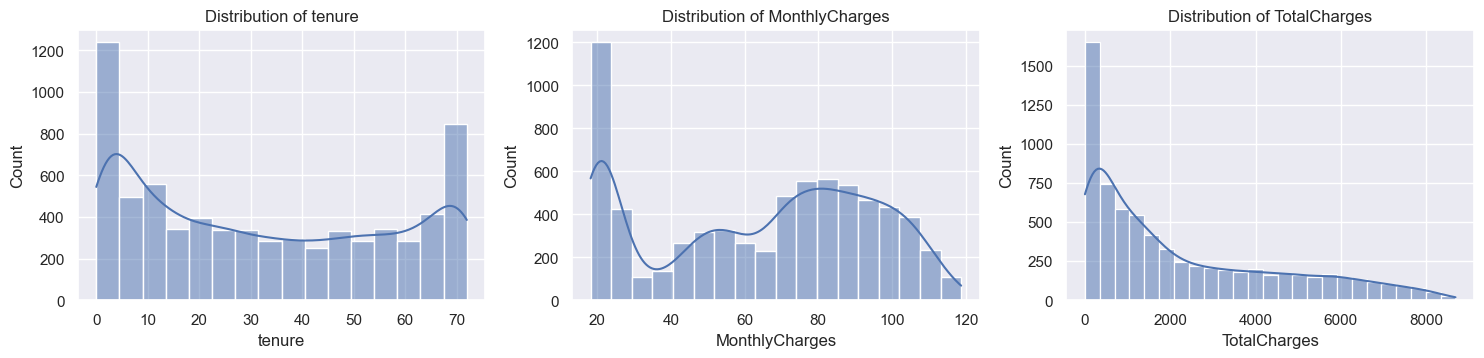

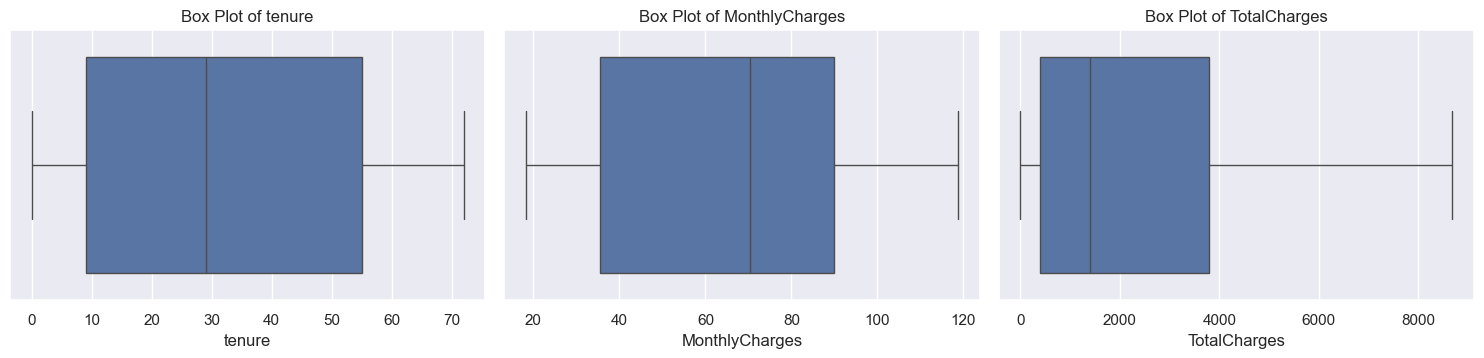

In [32]:
# show the distribution of the data
plt.figure(figsize=(15,10))
for i,column in enumerate(['tenure', 'MonthlyCharges', 'TotalCharges'], 1):
    plt.subplot(3,3,i)
    sns.histplot(df[column],kde=True)
    plt.title(f"Distribution of {column}")
plt.tight_layout()
plt.show()

# show the boxplot of the data
plt.figure(figsize=(15,10))
for i,column in enumerate(['tenure', 'MonthlyCharges', 'TotalCharges'], 1):
    plt.subplot(3,3,i)
    sns.boxplot(x=df[column])
    plt.title(f"Box Plot of {column}")
plt.tight_layout()
plt.show()



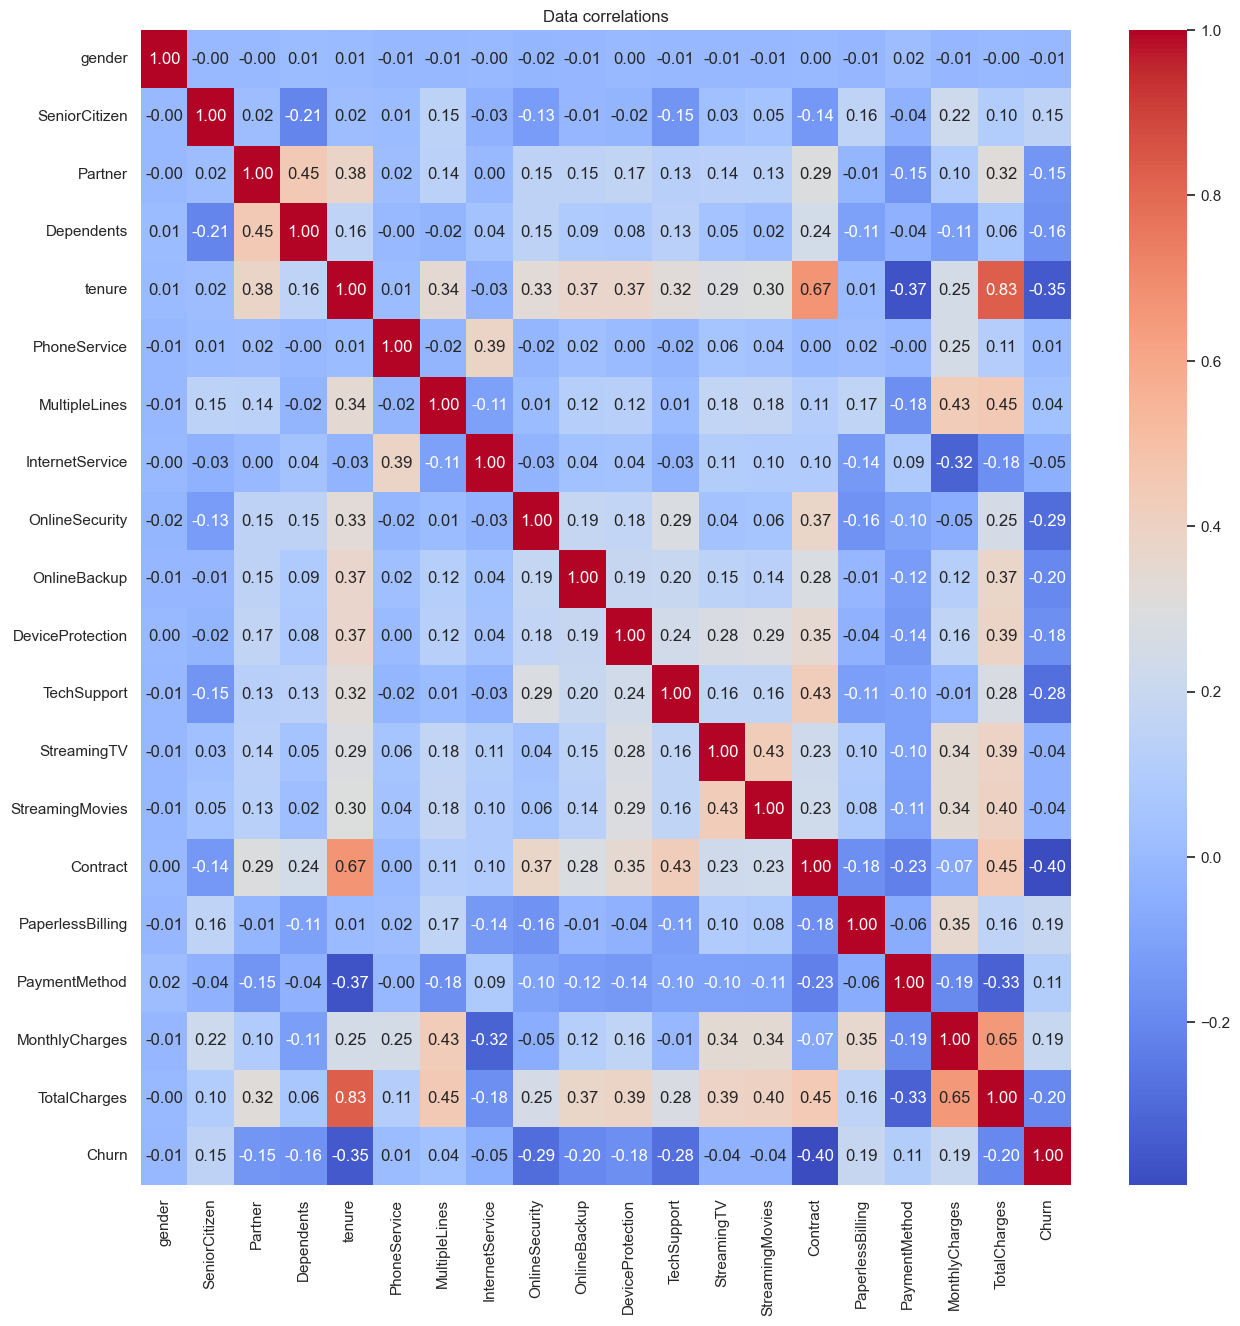

In [33]:
plt.figure(figsize=(15,15))
sns.heatmap(df.corr(),annot=True,fmt='.2f',cmap='coolwarm')
plt.title('Data correlations')
plt.show()

> **INSIGHTS**
>   - we encoded columns
>   - "Churn" is unbalance
>   - we droped "customer id" 
>   - No outiers
>   - needed to be standardized --> ['tenure', 'MonthlyCharges', 'TotalCharges']
>---


### DATA SPLITTING

In [34]:
x = df.drop('Churn', axis=1)
y = df['Churn']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

In [35]:
# only scale numerical columns
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()
x_train[numerical_cols] = scaler.fit_transform(x_train[numerical_cols])
x_test[numerical_cols]  = scaler.transform(x_test[numerical_cols])


### MODEL TRAINING

#### models

In [36]:
# models with class_weight balanced
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    'Decision Tree'      : DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest'      : RandomForestClassifier(class_weight='balanced', random_state=42),
    'XGBoost'            : XGBClassifier(scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum(), random_state=42)
}

#### hyper parameter tunning

In [37]:
# param distributions for each model
param_dist = {
    'Logistic Regression': {
        'C'      : [0.01, 0.1, 1, 10, 100],
        'solver' : ['lbfgs', 'liblinear']
    },
    'Decision Tree': {
        'max_depth'        : [None, 5, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf' : [1, 2, 4],
        'criterion'        : ['gini', 'entropy']
    },
    'Random Forest': {
        'n_estimators'     : [50, 100, 200, 300],
        'max_depth'        : [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf' : [1, 2, 4],
        'max_features'     : ['sqrt', 'log2']
    },
    'XGBoost': {
        'n_estimators' : [50, 100, 200, 300],
        'max_depth'    : [3, 5, 7, 10],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'subsample'    : [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0]
    }
}

In [38]:
best_models ={}
best_params ={}

# define stratified k-fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# loop through each model
for model_name, model in models.items():
    print(f"Tuning {model_name}...")

    random_search = RandomizedSearchCV(
        estimator           = model,
        param_distributions = param_dist[model_name],
        cv                  = skf,
        scoring             = 'f1',
        n_iter              = 25,   
        n_jobs              = -1,
        random_state        = 42,
        verbose             = 1
    )

    random_search.fit(x_train, y_train)

    best_models[model_name] = random_search.best_estimator_
    best_params[model_name] = random_search.best_params_

    print(f"Best params : {random_search.best_params_}")
    print(f"Best score  : {random_search.best_score_:.2f}")
    print("-" * 50)

Tuning Logistic Regression...
Fitting 5 folds for each of 10 candidates, totalling 50 fits


d:\download_99\Anaconda\envs\Machine_Learning_env\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 10 is smaller than n_iter=25. Running 10 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best params : {'solver': 'lbfgs', 'C': 1}
Best score  : 0.63
--------------------------------------------------
Tuning Decision Tree...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best params : {'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 5, 'criterion': 'gini'}
Best score  : 0.61
--------------------------------------------------
Tuning Random Forest...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best params : {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 10}
Best score  : 0.63
--------------------------------------------------
Tuning XGBoost...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best params : {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.6}
Best score  : 0.63
--------------------------------------------------


### MODEL EVALUATION


Logistic Regression
Accuracy: 0.74
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.50      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



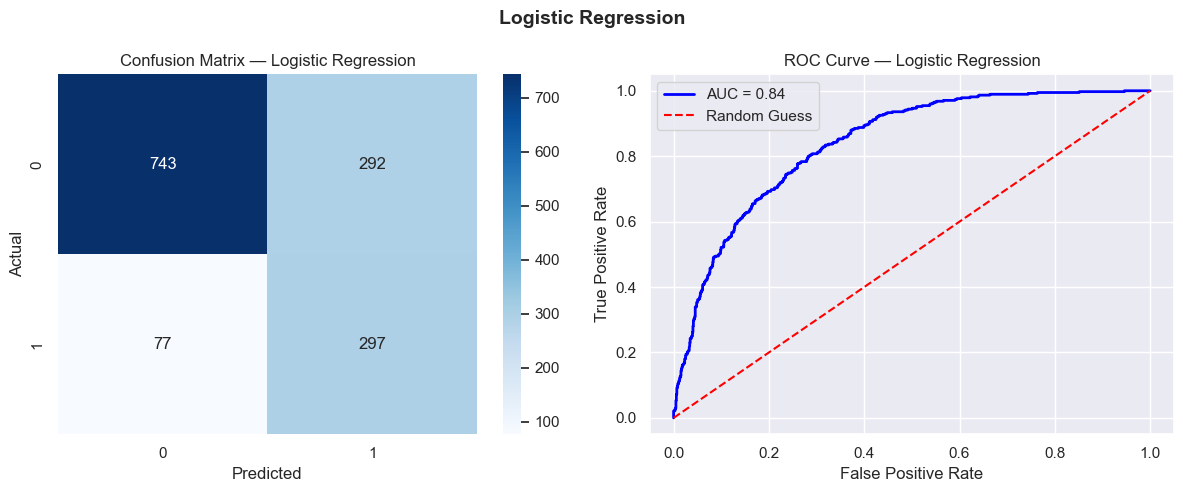


Decision Tree
Accuracy: 0.76
              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1035
           1       0.54      0.71      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.76      0.77      1409



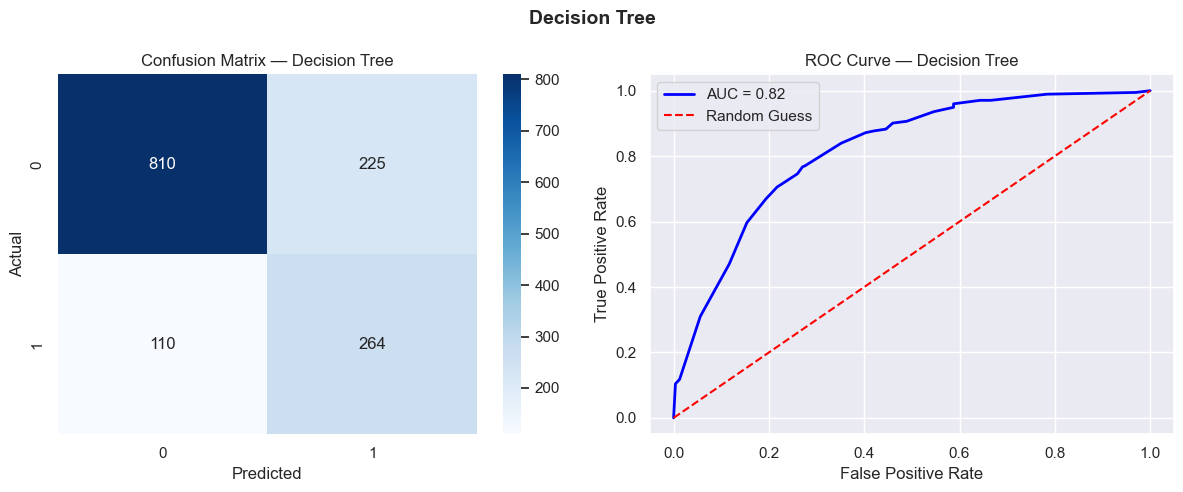


Random Forest
Accuracy: 0.77
              precision    recall  f1-score   support

           0       0.88      0.79      0.83      1035
           1       0.55      0.70      0.61       374

    accuracy                           0.77      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.77      0.78      1409



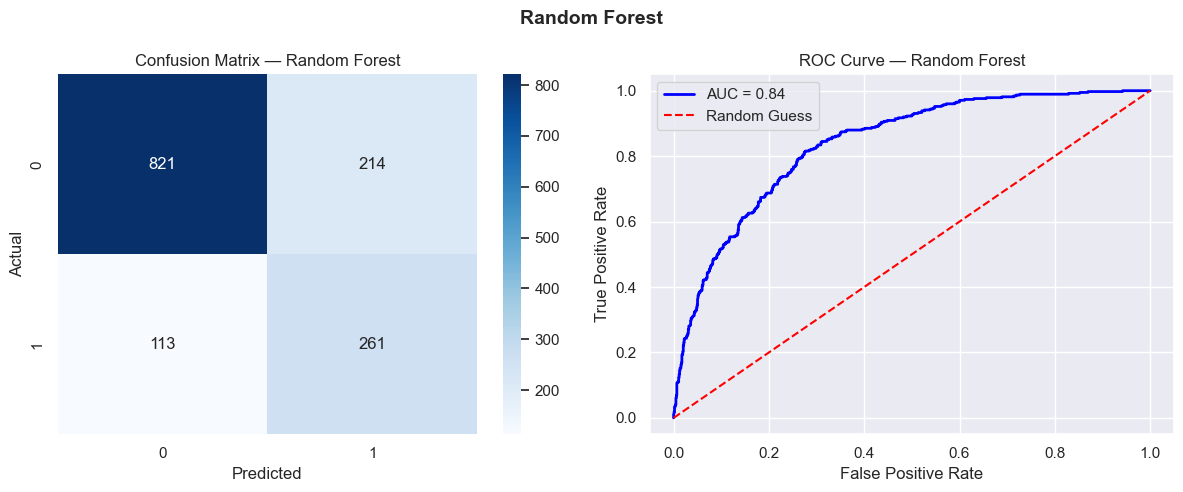


XGBoost
Accuracy: 0.74
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



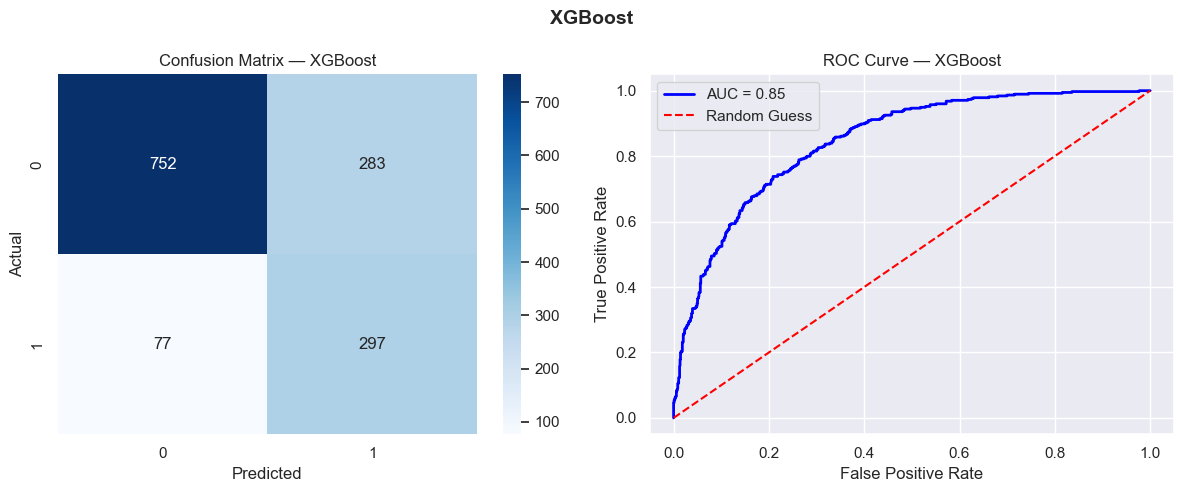

In [39]:
for model_name, model in best_models.items():
    y_pred = model.predict(x_test)
    y_prob = model.predict_proba(x_test)[:, 1]

    # accuracy & classification report
    print(f"\n{model_name}")
    print("=" * 50)
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
    print(classification_report(y_test, y_pred))

    # confusion matrix + ROC curve side by side
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # left → confusion matrix
    sns.heatmap(confusion_matrix(y_test, y_pred),annot=True, fmt='d', cmap='Blues',ax=axes[0])
    axes[0].set_title(f'Confusion Matrix — {model_name}')
    axes[0].set_ylabel('Actual')
    axes[0].set_xlabel('Predicted')

    # right → ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score   = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color='blue', linewidth=2, label=f'AUC = {auc_score:.2f}')
    axes[1].plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guess')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'ROC Curve — {model_name}')
    axes[1].legend()
    axes[1].grid(True)

    plt.suptitle(model_name, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

### SAVE MODEL

In [40]:
saved_model = {
    "model": best_models['Random Forest'],
    "scaler": scaler,
    "encoders": encoders,
    "feature_names": x.columns.tolist()
}

with open('churn_model.pkl', 'wb') as f:
    pickle.dump(saved_model, f)


In [41]:
# model load 

with open('churn_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

model = loaded_model['model']
scaler = loaded_model['scaler']
encoders = loaded_model['encoders']
feature_names = loaded_model['feature_names']

In [44]:
input_data = ({
    'gender': 'Male',
    'SeniorCitizen': 0,
    'Partner': 'No',
    'Dependents': 'No',
    'tenure': 2,
    'PhoneService': 'Yes',
    'MultipleLines': 'No',
    'InternetService': 'DSL',
    'OnlineSecurity': 'Yes',
    'OnlineBackup': 'Yes',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'No',
    'StreamingMovies': 'No',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Mailed check',
    'MonthlyCharges': 53.85,
    'TotalCharges': 108.15
})

In [45]:
# conver input data to dataframe
input_df = pd.DataFrame([input_data])

# apply encoding
for col, encoder in encoders.items():
    if col in input_df.columns:
        input_df[col] = encoder.transform(input_df[col])

# scaling
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
input_df[numerical_cols] = scaler.transform(input_df[numerical_cols])

prediction = model.predict(input_df)[0]


print(f"Prediction: {'Churn' if prediction == 1 else 'No Churn'}")


Prediction: Churn
